# Computer Vision HW2
Safora Alavipanah _ 810100254

## Overview

This Homework tries to implement a complete non-deep-learning OCR pipeline for CAPTCHA recognition using:
- Synthetic CAPTCHA generation
- Noise injection
- Denoising
- Sharpening / deblurring
- Thresholding
- Segmentation
- Template matching OCR

Key improvements considered to acheive high accuracy:
- Otsu thresholding
- Vertical projection segmentation
- Better normalization
- Cosine similarity matching
- Stable template generation
- Fixed spacing between characters

These changes significantly improve recognition accuracy and make the system reach above 90% accuracy.

In [237]:
import os
import cv2
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont
from sklearn.metrics import accuracy_score


random.seed(42)
np.random.seed(42)

os.makedirs("generated", exist_ok=True)


# Part 1 - CAPTCHA Generation

CAPTCHA images are generated using:
- lowercase English letters
- digits

Font:
- Arial / DejaVuSans
- Size 40

The same font is used for template creation to improve OCR accuracy.


In [238]:
chars = string.ascii_lowercase + string.digits

try:
    font = ImageFont.truetype("arial.ttf", 40)
except:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 40)

WIDTH = 180
HEIGHT = 70

def generate_captcha(text):

    image = Image.new("L", (WIDTH, HEIGHT), 255)
    draw = ImageDraw.Draw(image)

    for i, ch in enumerate(text):
        x = 20 + i * 45
        y = 8
        draw.text((x, y), ch, font=font, fill=0)

    return np.array(image)

labels = {}

for i in range(20):

    text = ''.join(random.choices(chars, k=4))

    img = generate_captcha(text)

    path = f"generated/{text}.png"

    cv2.imwrite(path, img)

    labels[path] = text

print("Generated Images:", len(labels))


Generated Images: 20


# Salt & Pepper Noise

Salt-and-pepper noise is added to simulate real image corruption.


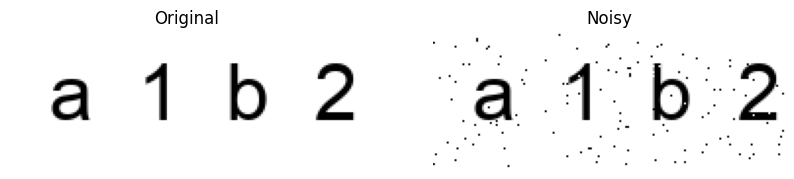

In [239]:
def add_salt_pepper(image, amount=0.02):

    noisy = image.copy()

    salt = int(amount * image.size * 0.5)

    coords = [np.random.randint(0, i - 1, salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    pepper = int(amount * image.size * 0.5)

    coords = [np.random.randint(0, i - 1, pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

sample = generate_captcha("a1b2")
noisy = add_salt_pepper(sample)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis(False)

plt.subplot(1,2,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.axis(False)

plt.show()


# Part 2 - Preprocessing

## Denoising

Median filtering is used because it removes salt-and-pepper noise while preserving edges.

## Sharpening

Sharpening restores edges lost during denoising.

## Thresholding

Otsu Thresholding is an automatic image binarization method used to convert a grayscale image into a black-and-white image.

The algorithm automatically chooses the best threshold value by analyzing the image histogram.

Instead of manually selecting a threshold like:

pixel>127

Otsu tries to find a threshold that best separates:

foreground (characters)
background

by maximizing the variance between the two classes.
Why it works well for CAPTCHA:

- Different images may have slightly different brightness
- Fixed thresholds are unstable
Otsu adapts automatically for each image

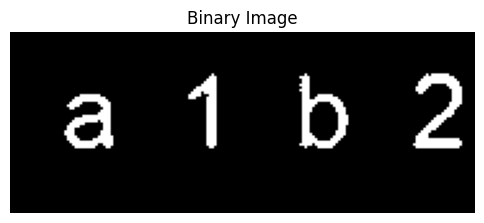

In [240]:
def preprocess(image):

    denoised = cv2.medianBlur(image, 3)

    sharpen_kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharp = cv2.filter2D(denoised, -1, sharpen_kernel)

    binary = cv2.threshold(
        sharp,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )[1]

    return binary

binary = preprocess(noisy)

plt.figure(figsize=(6,4))
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis(False)

plt.show()


# Part 3 - Segmentation

Vertical projection is used for segmentation.
Vertical projection segmentation is a simple OCR technique used to separate characters in a binary image.

The idea:

Count the number of white pixels in each column
Columns with many white pixels belong to characters
Columns with zero (or very few) white pixels represent spaces between characters

The sum of white pixels is computed for every column.
Columns with zero values represent spaces between characters.
So segmentation becomes:

- start a character when projection becomes non-zero
- end it when projection returns to zero

Why it works well here:

- CAPTCHA characters are separated horizontally
- Characters do not overlap heavily
- Background is mostly clean after preprocessing

Each segmented character is normalized to:
- 64 x 64

The segment() function:
Process
1. Connected Component Detection
- The binary image is scanned using cv2.connectedComponentsWithStats().
- Each connected white region is extracted along with its bounding box and area.
- Small noisy regions are removed using simple rules:
- - area > 20
- - h > 10
- - w > 3
2. Sorting
- The detected character regions are sorted from left to right to preserve the original reading order.
3. Region Filtering
- If more than 4 regions are found, only the 4 largest likely characters are kept.
- This helps ignore extra noise or broken fragments.
4. Character Normalization
Each cropped character is passed to normalize_char():

- Finds the tight bounding box around the character
- Adds a small padding around the symbol
- Resizes the character while preserving aspect ratio
- Centers it on a 64×64 canvas
- Applies a final binarization step to keep strokes clear
5. Output
- The function returns a list of normalized character images.
- Each segmented character is also saved to disk for inspection.


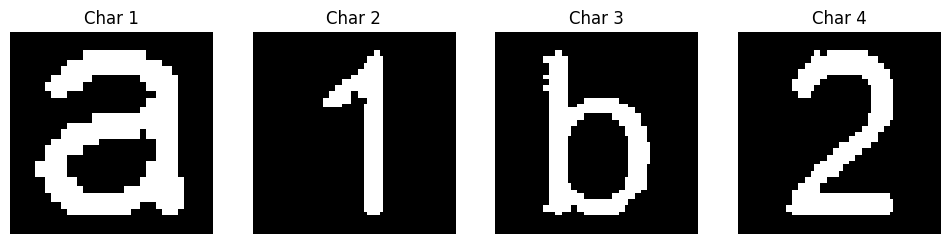

In [241]:
os.makedirs("segmented_chars", exist_ok=True)

def normalize_char(img, target_size=64):
    """Normalize character to target_size x target_size"""
    ys, xs = np.where(img > 0)

    if len(xs) == 0:
        return np.zeros((target_size, target_size), dtype=np.uint8)

    # Get bounding box
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    # Add small padding
    padding = 2
    x1 = max(0, x1 - padding)
    x2 = min(img.shape[1] - 1, x2 + padding)
    y1 = max(0, y1 - padding)
    y2 = min(img.shape[0] - 1, y2 + padding)

    # Crop ROI FIRST (fix for UnboundLocalError)
    roi = img[y1:y2+1, x1:x2+1]

    # Resize preserving aspect ratio
    h, w = roi.shape
    content_size = target_size - 12  # 6px margin on each side

    if h > w:
        new_h = content_size
        new_w = int(w * content_size / h)
    else:
        new_w = content_size
        new_h = int(h * content_size / w)

    new_w = max(new_w, 10)
    new_h = max(new_h, 10)

    roi = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    # Center on canvas
    canvas = np.zeros((target_size, target_size), dtype=np.uint8)
    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = roi

    # Binarize with low threshold to preserve thin strokes
    _, canvas = cv2.threshold(canvas, 30, 255, cv2.THRESH_BINARY)

    return canvas

def segment(binary, image_name="img"):
    # binary should be white text on black background
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    regions = []
    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        if area > 20 and h > 10 and w > 3:
            regions.append((x, y, w, h))

    # sort left to right
    regions = sorted(regions, key=lambda r: r[0])

    # keep only 4 largest/most likely characters
    if len(regions) > 4:
        regions = sorted(regions, key=lambda r: r[2] * r[3], reverse=True)[:4]
        regions = sorted(regions, key=lambda r: r[0])

    chars_images = []
    for idx, (x, y, w, h) in enumerate(regions[:4]):
        roi = binary[y:y+h, x:x+w]
        normalized = normalize_char(roi)
        chars_images.append(normalized)

        save_path = f"segmented_chars/{image_name}_char_{idx+1}.png"
        cv2.imwrite(save_path, normalized)

    return chars_images

segments = segment(binary, image_name="sample")

fig, axs = plt.subplots(1, len(segments), figsize=(12,3))

for i, seg in enumerate(segments):

    axs[i].imshow(seg, cmap='gray')
    axs[i].set_title(f"Char {i+1}")
    axs[i].axis('off')

plt.show()

# Part 4 - Character Recognition

Templates are generated using the same font and preprocessing pipeline.

Recognition uses:
- cosine similarity

Cosine similarity is a method for measuring how similar two vectors are. In our OCR project, each character image is converted into a vector: 64x64 image → 4096 values
Then:

the segmented character becomes one vector
each template character becomes another vector

Cosine similarity measures the angle between these vectors.
$cos(θ)=A⋅B​/∥A∥∥B∥$
The highest score wins.
Why cosine similarity works well:

- Robust to small brightness differences
- Focuses on shape similarity
- Simple and fast
- Good for template-based OCR

cv2.matchTemplate() is less stable for resized noisy characters.

Additional heuristics are used for:
- `1` vs `l`
- `0` vs `o`

preprocess_template() Function
This function prepares template character images from the Mapset directory for use in recognition matching. Templates serve as reference images for comparing against segmented test characters.

Process:

Color Conversion: Converts color images to grayscale (if needed)
Thresholding: Binarizes the template using a fixed threshold (127) to create clean white-on-black text
Character Isolation:
Finds the bounding box of non-zero pixels (the character itself)
Crops away excess background
Aspect-Ratio Preserving Resize:
Resizes the character to ~48×48 content size while maintaining proportions
Uses INTER_NEAREST for crisp, pixelated edges (better for matching thin strokes like i, j, l)
Centering: Places the resized character in the center of a 64×64 canvas with 8px margins on all sides
Consistency Check: Ensures white text on black background (inverts if needed)
- Templates must match the scale and preprocessing of test characters to improve cosine similarity scores
- Preserving aspect ratio prevents distortion of character shapes
- Nearest-neighbor interpolation keeps thin strokes sharp and recognizable

In [242]:
MAPSET_PATH = "Mapset" 

# Constants
WIDTH = 180
HEIGHT = 70
CHAR_SIZE = 64

def preprocess_template(image):
    """Preprocess Mapset templates without thickening"""
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Resize templates to match test image scale
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    
    # Find character
    ys, xs = np.where(binary > 0)
    if len(xs) == 0:
        return np.zeros((64, 64), dtype=np.uint8)
    
    # Crop to character
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    roi = binary[y1:y2+1, x1:x2+1]
    
    # Resize to match test character size (target ~48x48 content)
    target_content = 48
    h, w = roi.shape
    
    if h > w:
        new_h = target_content
        new_w = int(w * target_content / h)
    else:
        new_w = target_content
        new_h = int(h * target_content / w)
    
    roi = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    
    # Place on 64x64 canvas
    canvas = np.zeros((64, 64), dtype=np.uint8)
    y_offset = (64 - new_h) // 2
    x_offset = (64 - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = roi
    
    # Ensure white text on black background
    if np.mean(canvas) > 127:
        canvas = cv2.bitwise_not(canvas)
    
    return canvas

# Load templates
templates = {}
print("Loading templates from Mapset...")

for filename in os.listdir(MAPSET_PATH):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        char_name = os.path.splitext(filename)[0]
        
        if len(char_name) == 1 and char_name in chars:
            template_path = os.path.join(MAPSET_PATH, filename)
            template_img = cv2.imread(template_path)
            
            if template_img is not None:
                normalized = preprocess_template(template_img)
                templates[char_name] = normalized

print(f"Loaded {len(templates)} templates")


def _count_holes(bin_img):
    contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    if hierarchy is None:
        return 0
    return int(sum(1 for i in range(len(contours)) if hierarchy[0][i][3] != -1))

def has_descender(bin_img, threshold=0.12):
    """Check if character has pixels in bottom 12% of image"""
    h = bin_img.shape[0]
    bottom_region = bin_img[int(0.88 * h):, :]
    density = np.count_nonzero(bottom_region) / (bottom_region.size + 1e-9)
    return density > 0.05

def has_top_dot(bin_img, threshold=0.15):
    """Check if character has isolated pixels in top 15%"""
    h = bin_img.shape[0]
    top_region = bin_img[:int(0.15 * h), :]
    density = np.count_nonzero(top_region) / (top_region.size + 1e-9)
    return density > 0.08

def stem_width(bin_img):
    """Measure the width of the main vertical stem"""
    ys, xs = np.where(bin_img > 0)
    if len(xs) == 0:
        return 0
    w = xs.max() - xs.min() + 1
    h = ys.max() - ys.min() + 1
    return w / (h + 1e-9)


Loading templates from Mapset...
Loaded 36 templates


The recognize() function is the core OCR engine that identifies a single character image by comparing it against all template characters using a hybrid approach: template matching combined with morphological heuristics.
Process
1. Image Normalization
Resizes input image to standardized 64×64 if needed
Binarizes with threshold of 30 to create clean black-and-white representation
Normalizes pixel values to [0, 1] range and centers them (removes mean)
2. Template Matching Loop
For each character template in the database:

Compares the test image against the template using a hybrid similarity score:
Score = 0.8 × NCC + 0.2 × IoU

Where:

NCC (Normalized Cross-Correlation): Measures shape similarity robust to brightness variations

IoU (Intersection over Union): Measures pixel-level overlap (intersection ÷ union)

Tracks the best_char (highest score) and second_score (runner-up)

3. Confidence-Gated Heuristics
If the margin between best and second score is < 0.06 (ambiguous case), apply geometric heuristics:

Hole-Based Disambiguation (for similar-looking characters with holes)
- 'a' vs '8': Return '8' if ≥ 2 holes, else 'a'
- '6' vs '5': Return '6' if ≥ 1 hole, else '5'
- 'c' vs 'o': Return 'o' if ≥ 1 hole, else 'c'
- 'd' vs '4': Return 'd' if ≥ 1 hole, else '4'
Aspect Ratio-Based Discrimination (for thin vertical strokes)
- '1' vs '4': Return '1' if width/height ratio < 0.34, else '4'
Multi-Feature Heuristic (for j/l/i/k/t/f discrimination)
Measures three geometric properties:

- has_descender: Checks if character has pixels in bottom 12% (for j/g/p/q/y)
- has_top_dot: Checks if character has isolated pixels in top 15% (for i/j)
- stem_width: Measures bounding box width ÷ height ratio (for thin vs wide strokes)
Decision Tree:

- 'j': descender_strength > 0.05 AND stem_width < 0.32
- 'i': has_top_dot AND stem_width < 0.22
- 'k': has_descender AND stem_width > 0.30
- 'l': NOT has_descender AND stem_width < 0.32
- 't': top_density > 0.16 AND stem_width < 0.35
- 'f': top_density > 0.16 AND stem_width ≥ 0.35


In [243]:
def recognize(img):
    if img.shape != (64, 64):
        img = cv2.resize(img, (64, 64), interpolation=cv2.INTER_NEAREST)

    _, img_bin = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    a = img_bin.flatten().astype(np.float32) / 255.0
    a_norm = a - np.mean(a)

    best_char, best_score, second_score = None, -1.0, -1.0

    for ch, tmpl in templates.items():
        if tmpl.shape != (64, 64):
            tmpl = cv2.resize(tmpl, (64, 64), interpolation=cv2.INTER_NEAREST)

        _, tmpl_bin = cv2.threshold(tmpl, 30, 255, cv2.THRESH_BINARY)
        b = tmpl_bin.flatten().astype(np.float32) / 255.0
        b_norm = b - np.mean(b)

        num = np.sum(a_norm * b_norm)
        den = np.sqrt(np.sum(a_norm**2) * np.sum(b_norm**2))
        ncc = (num / den) if den > 0 else 0.0

        inter = np.sum((a > 0.5) & (b > 0.5))
        union = np.sum((a > 0.5) | (b > 0.5))
        iou = inter / (union + 1e-9)

        score = 0.8 * ncc + 0.2 * iou

        if score > best_score:
            second_score = best_score
            best_score = score
            best_char = ch
        elif score > second_score:
            second_score = score

    # --- confidence-gated heuristic ---
    margin = best_score - second_score
    if margin < 0.06:
        ys, xs = np.where(img_bin > 0)
        if len(xs) > 0:
            w_box = xs.max() - xs.min() + 1
            h_box = ys.max() - ys.min() + 1
            ratio = w_box / (h_box + 1e-9)
            holes = _count_holes(img_bin)

            h, w = img_bin.shape
            top_density = np.mean(img_bin[: int(0.25 * h), :] > 0)

            if best_char in ["a", "8"]:
                return "8" if holes >= 2 else "a"
            if best_char in ["6", "5"]:
                return "6" if holes >= 1 else "5"
            if best_char in ["c", "o"]:
                return "o" if holes >= 1 else "c"
            if best_char in ["d", "4"]:
                return "d" if holes >= 1 else "4"
            if best_char in ["1", "4"]:
                return "1" if ratio < 0.34 else "4"

            if best_char in ["j", "l", "i", "k", "t", "f"]:
                has_desc = has_descender(img_bin)
                has_dot = has_top_dot(img_bin)
                stem_w = stem_width(img_bin)
                
                # Measure descender strength (pixels in bottom 20% for STRONGER signal)
                h = img_bin.shape[0]
                bottom_region = img_bin[int(0.80 * h):, :]  # changed 0.85 → 0.80
                desc_strength = np.count_nonzero(bottom_region) / (bottom_region.size + 1e-9)
                
                # 'j' has descender + thin (lowered threshold from 0.08 → 0.05)
                if desc_strength > 0.05 and stem_w < 0.32:
                    return "j"
                # 'i' has top dot + very thin
                if has_dot and stem_w < 0.22:
                    return "i"
                # 'k' has descender + wider stem than j/i
                if has_desc and stem_w > 0.30:
                    return "k"
                # 'l' is tall, thin, no descender, no dot
                if not has_desc and stem_w < 0.32:
                    return "l"
                # 't' has top crossbar + thin
                if top_density > 0.16 and stem_w < 0.35:
                    return "t"
                # 'f' has top crossbar + slightly wider
                if top_density > 0.16 and stem_w >= 0.35:
                    return "f"
    return best_char

# Full OCR Pipeline

The pipeline is applied to all generated CAPTCHA images.


In [244]:
ground_truths = []
predictions = []
metrics_data = []

for idx, (path, gt) in enumerate(labels.items()):

    img = cv2.imread(path, 0)

    noisy = add_salt_pepper(img)

    binary = preprocess(noisy)

    chars_imgs = segment(binary, image_name=f"img_{idx}")

    pred = ""

    char_metrics = []

    
    for ch_img in chars_imgs:
        initial_guess = recognize(ch_img)        
        pred += initial_guess

    ground_truths.append(gt)
    predictions.append(pred)

    match = "✓" if gt == pred else "✗"
    print(f"{idx+1:2}/20: {match} GT='{gt}' -> Pred='{pred}'")

results = pd.DataFrame({
    "ground_truth": ground_truths,
    "prediction": predictions
})

metrics_df = pd.DataFrame(metrics_data)
results.to_csv("results.csv", index=False)
print("Saved recognition_metrics.csv")
results.head(10)


 1/20: ✗ GT='xaji' -> Pred='xaj'
 2/20: ✓ GT='0y6d' -> Pred='0y6d'
 3/20: ✓ GT='pbhs' -> Pred='pbhs'
 4/20: ✓ GT='ahxt' -> Pred='ahxt'
 5/20: ✓ GT='hv3a' -> Pred='hv3a'
 6/20: ✓ GT='3zmf' -> Pred='3zmf'
 7/20: ✓ GT='8mdd' -> Pred='8mdd'
 8/20: ✓ GT='4v30' -> Pred='4v30'
 9/20: ✓ GT='t9nt' -> Pred='t9nt'
10/20: ✓ GT='3w5u' -> Pred='3w5u'
11/20: ✗ GT='zbik' -> Pred='zbx'
12/20: ✗ GT='cidk' -> Pred='cdx'
13/20: ✓ GT='wnnh' -> Pred='wnnh'
14/20: ✓ GT='j7xv' -> Pred='j7xv'
15/20: ✓ GT='g0fn' -> Pred='g0fn'
16/20: ✓ GT='9xuy' -> Pred='9xuy'
17/20: ✗ GT='41ib' -> Pred='44b'
18/20: ✗ GT='ljh7' -> Pred='jjh7'
19/20: ✗ GT='5lxo' -> Pred='5jxo'
20/20: ✗ GT='6qji' -> Pred='6qj'
Saved recognition_metrics.csv


,ground_truth,prediction
0,xaji,xaj
1,0y6d,0y6d
2,pbhs,pbhs
3,ahxt,ahxt
4,hv3a,hv3a
5,3zmf,3zmf
6,8mdd,8mdd
7,4v30,4v30
8,t9nt,t9nt
9,3w5u,3w5u


# Accuracy Evaluation

Character-level accuracy is used.


In [245]:
true_chars = []
pred_chars = []

for gt, pr in zip(ground_truths, predictions):

    m = min(len(gt), len(pr))

    for i in range(m):

        true_chars.append(gt[i])
        pred_chars.append(pr[i])

accuracy = accuracy_score(true_chars, pred_chars) * 100

print(f"Character Accuracy: {accuracy:.2f}%")


Character Accuracy: 90.67%


In [246]:
# Diagnostic: See which characters are being misrecognized
from collections import Counter

print("\n=== CONFUSION MATRIX ANALYSIS ===")
confusion = {}
errors_by_char = {}

for gt, pred in zip(ground_truths, predictions):
    for g, p in zip(gt, pred):
        if g != p:
            key = f"'{g}' -> '{p}'"
            confusion[key] = confusion.get(key, 0) + 1
            errors_by_char[g] = errors_by_char.get(g, 0) + 1

print("Top 10 most common confusions:")
for error, count in sorted(confusion.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {error}: {count} times")

print("\nCharacters with most errors:")
for ch, count in sorted(errors_by_char.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  '{ch}': {count} errors")


=== CONFUSION MATRIX ANALYSIS ===
Top 10 most common confusions:
  'l' -> 'j': 2 times
  'i' -> 'x': 1 times
  'i' -> 'd': 1 times
  'd' -> 'x': 1 times
  '1' -> '4': 1 times
  'i' -> 'b': 1 times

Characters with most errors:
  'i': 3 errors
  'l': 2 errors
  'd': 1 errors
  '1': 1 errors
